# Estimation of R
Rを求めて海表面情報を探索する試み。

In [69]:
# 依存パッケージをimport

import os

from gnssrefl.utils import check_environment, set_environment, get_sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pywt

# import gnssrefl functions
from gnssrefl.rinex2snr_cl import rinex2snr
from gnssrefl.gnssir_cl import gnssir

#@formatter:off
%matplotlib inline

## RINEX → SNR

下記ディレクトリにRINEXファイルを入れる。

refl_code/yyyy/rinex/TTTT/TTTTXXX0.yyo
- yyyy：西暦
- TTTT：局名。アルファベット4文字。
- XXX：day of year
- yy：西暦下二桁

In [4]:
year = 2020
doy = 277
doy_end = 288
station = "calc"

rinex2snr(station, year, doy, doy_end=doy_end, nolook=True)

Using JSON file: /etc/gnssrefl/refl_code/input/calc/calc.json
Using snr value of  66
Using default orbit for this time period:  nav
Using archive value of  all
Station  calc  has four characters, assume RINEX 2.11 format
No parallel processing
SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2770.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2780.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2790.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2800.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2810.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2820.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2830.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2840.20.snr66 

SNR file already exists /etc/gnssrefl/refl_code/2020/snr/calc/calc2850.20.snr66 

SNR file already e

## SNRファイルの読み込み

In [34]:
from pathlib import Path
import pandas as pd
import numpy as np

# SNR ファイルのカラム名（マニュアル準拠）
SNR_COLUMNS_FULL = [
    "sat",              # 衛星番号
    "elev_deg",         # 仰角 [deg]
    "az_deg",           # 方位角 [deg]
    "sec_of_day",       # 秒（GPS time）
    "edot_deg_per_s",   # 仰角変化率 [deg/s]
    "snr_L6",           # S6 (L6) SNR [dB-Hz]
    "snr_L1",           # S1 (L1)
    "snr_L2",           # S2 (L2)
    "snr_L5",           # S5 (L5)
    "snr_L7",           # S7 (L7)
    "snr_L8",           # S8 (L8)
]


def read_snr_file_gz(path: Path) -> pd.DataFrame:
    """1つの .snr*.gz ファイルを読み込んで DataFrame を返す。"""
    df = pd.read_csv(
        path,
        sep=r"\s+",        # ← FutureWarning 回避
        header=None,
        comment="#",
        compression="gzip",
        engine="python",
    )
    n_cols = df.shape[1]
    df.columns = SNR_COLUMNS_FULL[:n_cols]
    return df


def load_snr_directory(year: int, station: str,
                       base_dir: str = "/etc/gnssrefl/refl_code"):
    """
    /etc/gnssrefl/refl_code/{year}/snr/{station}/ 配下の
    .snr*.gz ファイルだけを全部読み込んで

    - snr_dict: {ファイル名: DataFrame}
    - snr_table: 全ファイルを縦結合した DataFrame
                 (year, station, doy, file などの情報付き)

    を返す。
    """
    snr_dir = Path(base_dir) / str(year) / "snr" / station

    if not snr_dir.is_dir():
        raise FileNotFoundError(f"ディレクトリが見つかりません: {snr_dir}")

    snr_files = sorted(snr_dir.glob("*.snr*.gz"))

    if not snr_files:
        print(f"*.snr*.gz が見つかりません: {snr_dir}")

    snr_dict = {}
    table_list = []

    for f in snr_files:
        df = read_snr_file_gz(f)
        snr_dict[f.name] = df

        # ファイル名から DOY を推定（例: calc2770.20.snr66.gz）
        name_no_gz = f.name[:-3] if f.name.endswith(".gz") else f.name
        stem = name_no_gz.split(".")[0]   # "calc2770"
        doy = int(stem[len(station):len(station) + 3])  # "277"

        df2 = df.copy()
        df2["year"] = year
        df2["station"] = station
        df2["file"] = f.name
        df2["doy"] = doy
        table_list.append(df2)

    if table_list:
        snr_table = pd.concat(table_list, ignore_index=True)
    else:
        snr_table = pd.DataFrame()

    return snr_dict, snr_table

def main(year: int,
         station: str,
         snr_dict_existing=None,
         base_dir: str = "/etc/gnssrefl/refl_code"):
    """
    - Jupyter で既に snr_dict を作っているなら snr_dict_existing を渡す
    - そうでなければディレクトリから読み込む

    戻り値:
        snr_dict, snr_table
    """
    if snr_dict_existing is None:
        snr_dict, snr_table = load_snr_directory(year, station, base_dir=base_dir)
    else:
        # 既存の snr_dict から snr_table だけ再構成したい場合など
        snr_dict = snr_dict_existing
        # ここで snr_table を組み立て直すなら、上の build 処理を使い回すイメージ
        # 必要なら別関数に分けてもよい
        rows = []
        for fname, df in snr_dict.items():
            name_no_gz = fname[:-3] if fname.endswith(".gz") else fname
            stem = name_no_gz.split(".")[0]
            doy = int(stem[len(station):len(station) + 3])

            tmp = df.copy()
            tmp["year"] = year
            tmp["station"] = station
            tmp["file"] = fname
            tmp["doy"] = doy
            rows.append(tmp)
        snr_table = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

    return snr_dict, snr_table


## コヒーレント・インコヒーレント比率を求める

### Plot用

In [89]:
import matplotlib.pyplot as plt

def plot_R_e(e: np.ndarray, R: np.ndarray, title: str | None = None):
    plt.figure()
    plt.plot(e, R)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("R(e) = P_inc / P_coh")
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.show()
    plt.figure()
    R_dB = 10 * np.log10(R)
    plt.plot(e, R_dB)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("R(e) = P_inc / P_coh [dB]")
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.show()
    


def plot_wavelet_power_e_h(e_grid, h_grid, P, title=None):
    import numpy as np
    import matplotlib.pyplot as plt

    e_grid = np.asarray(e_grid)
    h_grid = np.asarray(h_grid)
    P = np.asarray(P, float)

    if P.shape != (len(e_grid), len(h_grid)):
        raise ValueError(
            f"P.shape={P.shape}, expected ({len(e_grid)}, {len(h_grid)})"
        )

    # 0 以上に限定
    P[P < 0] = 0.0
    Pmax = np.nanmax(P)
    if not np.isfinite(Pmax) or Pmax <= 0:
        Pmax = 1.0  # 全部ゼロだったときの保険

    E, H = np.meshgrid(e_grid, h_grid, indexing="xy")

    plt.figure()
    pcm = plt.pcolormesh(E, H, P.T, shading="auto", vmin=0.0, vmax=Pmax)
    plt.xlabel("Elevation e [deg]")
    plt.ylabel("Height h [m]")
    if title is not None:
        plt.title(title)
    cb = plt.colorbar(pcm)
    cb.set_label(r"$|W(e,h)|^2$")
    plt.tight_layout()
    plt.show()



読み込み完了


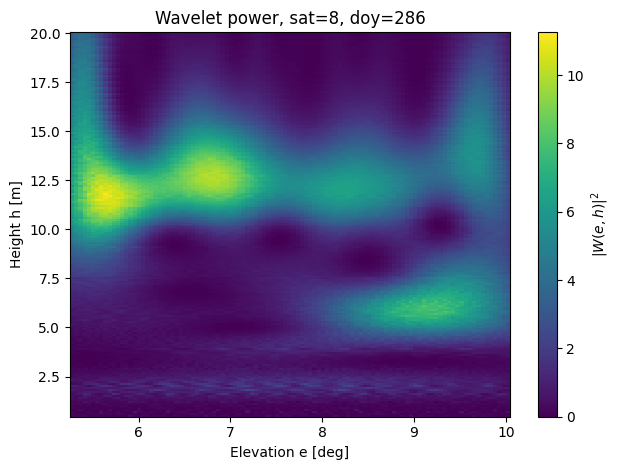

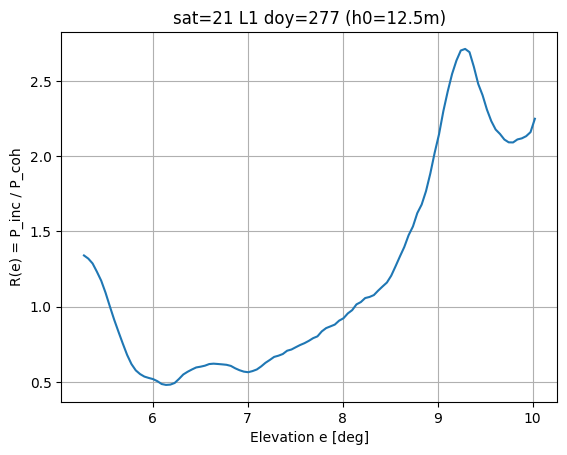

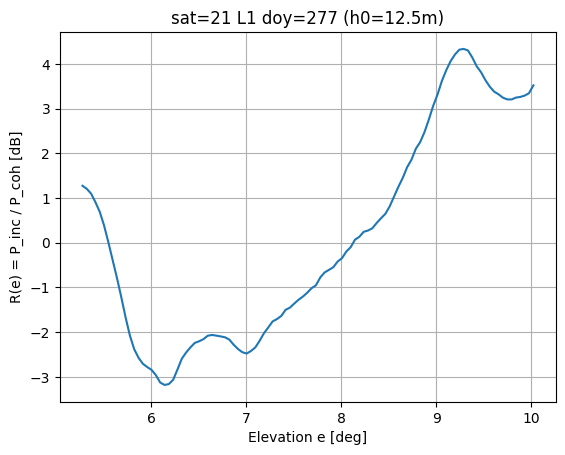

In [97]:
LAMBDA_L1 = 0.190293672798365  # [m] GNSS L1 の波長

def detrend_snr_gnss_ir(x, y, poly_order: int = 2):
    coef = np.polyfit(x, y, poly_order)
    trend = np.polyval(coef, x)
    return y - trend, trend


def compute_wavelet_power_e_h(
    elev_deg: np.ndarray,
    snr_series: np.ndarray,
    h_grid: np.ndarray,
    wavelength_m: float = LAMBDA_L1,
    wavelet_name: str = "cmor1.5-1.0",
):
    elev_deg = np.asarray(elev_deg, float)
    snr_series = np.asarray(snr_series, float)
    h_grid = np.asarray(h_grid, float)

    # 1) x = sin(e)
    x = np.sin(np.deg2rad(elev_deg))
    order = np.argsort(x)
    x = x[order]
    y = snr_series[order]

    # 2) 等間隔 x グリッド
    N = len(x)
    x_uniform = np.linspace(x[0], x[-1], N)
    y_uniform = np.interp(x_uniform, x, y)

    # 3) トレンド除去
    y_detr, trend = detrend_snr_gnss_ir(x_uniform, y_uniform, poly_order=2)

    # 4) CWT 準備
    dt = x_uniform[1] - x_uniform[0]
    wavelet = pywt.ContinuousWavelet(wavelet_name)
    f_c = pywt.central_frequency(wavelet)

    # 5) h_grid -> scale
    #   f_x = 2h / λ
    #   scale = f_c / (f_x * dt) = λ f_c / (2 h dt)
    scales = np.zeros_like(h_grid, dtype=float)
    valid = h_grid > 0

    f_x = np.zeros_like(h_grid, dtype=float)
    f_x[valid] = 2.0 * h_grid[valid] / wavelength_m
    scales[valid] = f_c / (f_x[valid] * dt)  # = λ f_c / (2 h dt)

    valid_idx = np.where(valid & np.isfinite(scales) & (scales > 0))[0]
    scales_valid = scales[valid_idx]
    if len(scales_valid) == 0:
        raise ValueError("有効なスケールが 1 つもありません。h_grid の範囲を見直してください。")

    # 6) CWT 実行
    coeffs, _ = pywt.cwt(y_detr, scales_valid, wavelet, sampling_period=dt)
    power_valid = np.abs(coeffs) ** 2  # (n_scales_valid, N)

    # 7) P(e,h) に展開
    P = np.zeros((N, len(h_grid)), dtype=float)
    for j, h_idx in enumerate(valid_idx):
        P[:, h_idx] = power_valid[j, :]

    # 8) x -> e_grid [deg]
    e_grid = np.rad2deg(np.arcsin(x_uniform))

    return e_grid, h_grid, P

def compute_R_from_power(
    e_grid: np.ndarray,
    h_grid: np.ndarray,
    P: np.ndarray,
    h0: float,
    delta_h: float = 4.0,   # 真のRHからの距離
    w_at_delta: float = 0.1,
    sigma_coh: float | None = None,
):
    """
    P(e,h) から R(e) を計算する。

    引数:
        e_grid   : shape (Ne,) 仰角 [deg]
        h_grid   : shape (Nh,) 高さ [m]
        P        : shape (Ne, Nh) パワー P(e,h)
        h0       : 真の RH [m]
        delta_h  : h0 からの距離 Δh (デフォルト 2.5m)
        w_at_delta : Δh のときの重み w (デフォルト 0.1)
        sigma_coh : 直接 σ_coh を指定したければ与える。
                    None のときは Δh, w から計算。

    戻り値:
        dict でまとめて返す:
            {
              "e": e_grid,
              "P_coh": P_coh(e),
              "P_total": P_total(e),
              "P_inc": P_inc(e),
              "R": R(e),
              "sigma_coh": sigma_coh,
            }
    """
    e_grid = np.asarray(e_grid)
    h_grid = np.asarray(h_grid)
    P = np.asarray(P)

    if P.shape != (len(e_grid), len(h_grid)):
        raise ValueError(f"P の shape が (Ne,Nh)={P.shape} ですが、"
                         f"Ne={len(e_grid)}, Nh={len(h_grid)} と一致していません。")

    if sigma_coh is None:
        sigma_coh = delta_h / np.sqrt(2.0 * np.log(1.0 / w_at_delta))

    # ガウス窓 w_coh(h)
    w_coh = np.exp(-(h_grid - h0) ** 2 / (2.0 * sigma_coh ** 2))  # shape (Nh,)

    # P_coh(e) = Σ_h w_coh(h) P(e,h)
    # P_total(e) = Σ_h P(e,h)
    # ブロードキャストで計算
    P_coh = np.sum(P * w_coh[None, :], axis=1)
    P_total = np.sum(P, axis=1)
    P_inc = P_total - P_coh

    # ゼロ除算を避けるために where 指定
    with np.errstate(divide="ignore", invalid="ignore"):
        R = np.where(P_coh > 0, P_inc / P_coh, np.nan)

    return {
        "e": e_grid,
        "P_coh": P_coh,
        "P_total": P_total,
        "P_inc": P_inc,
        "R": R,
        "sigma_coh": sigma_coh,
    }

# 信号名→カラム名
SIGNAL_COL_MAP = {
    "L1": "snr_L1",
    "L2": "snr_L2",
    "L5": "snr_L5",
    "L6": "snr_L6",
    "L7": "snr_L7",
    "L8": "snr_L8",
}

# Azimuth範囲フィルタ
def normalize_angle_deg(angle: float) -> float:
    """角度を 0〜360° に正規化。"""
    return float(np.mod(angle, 360.0))


def azimuth_in_range(az: pd.Series, az_min: float, az_max: float) -> pd.Series:
    """
    az_min〜az_max の範囲に入るかどうかを返す。
    - az は 0〜360° を想定
    - az_min, az_max は負でも 360 超でも OK（mod 360 で正規化）
    - 範囲が 360° をまたぐ場合（例: 300〜60°）も OR 条件で扱う
    """
    az_mod = np.mod(az.to_numpy(), 360.0)

    amin = normalize_angle_deg(az_min)
    amax = normalize_angle_deg(az_max)

    if amin <= amax:
        mask = (az_mod >= amin) & (az_mod <= amax)
    else:
        # 例: amin=290, amax=140 のとき
        # 290〜360° または 0〜140°
        mask = (az_mod >= amin) | (az_mod <= amax)

    return pd.Series(mask, index=az.index)

def add_direction_by_elev(df: pd.DataFrame, eps: float = 1e-3) -> pd.DataFrame:
    """
    sec_of_day の順に並べ、仰角の差分から昇り/下りを判定して
    'direction_flag' カラムに 'up' / 'down' / 'flat' を入れる。
    """
    if df.empty:
        df["direction_flag"] = []
        return df

    df = df.sort_values("sec_of_day").copy()

    de = df["elev_deg"].diff()  # 1 ステップ前との差
    # 先頭 NaN は 0 として処理
    de.iloc[0] = de.iloc[1] if len(de) > 1 else 0.0

    dir_flag = np.where(
        de > eps, "up",
        np.where(de < -eps, "down", "flat")
    )

    df["direction_flag"] = dir_flag
    return df


def select_observations(
    snr_table: pd.DataFrame,
    doy: int | None = None,
    sat: int | None = None,
    signal: str = "L1",
    az_range: tuple[float, float] | None = None,
    direction: str | None = None,
):
    """
    GNSS-IR 解析に使う観測点をフィルタする。

    引数:
        snr_table : main()/load_snr_directory() で作ったテーブル
        doy       : day of year。None なら全 DOY。
        sat       : 衛星番号。None なら全衛星。
        signal    : "L1", "L2", ... どの信号を使うか。
        az_range  : (az_min, az_max) [deg]。負/360超 OK。
        direction : None / "up" / "down"
                    → 仰角の変化から判定する。
    戻り値:
        df_sel: フィルタ後 DataFrame
        signal_col: 使用する SNR カラム名
    """
    if signal not in SIGNAL_COL_MAP:
        raise ValueError(f"未知の signal: {signal}. {list(SIGNAL_COL_MAP.keys())} から選んでください。")

    signal_col = SIGNAL_COL_MAP[signal]

    df = snr_table.copy()

    if doy is not None:
        df = df[df["doy"] == doy]

    if sat is not None:
        df = df[df["sat"] == sat]

    if az_range is not None:
        az_min, az_max = az_range
        mask_az = azimuth_in_range(df["az_deg"], az_min, az_max)
        df = df[mask_az]

    # 昇り/下り判定を仰角から付与
    if direction is not None:
        df = add_direction_by_elev(df)
        if direction == "up":
            df = df[df["direction_flag"] == "up"]
        elif direction == "down":
            df = df[df["direction_flag"] == "down"]
        # "flat" は捨てている

    # 最終的には仰角順に並べておく
    df = df.sort_values("elev_deg").reset_index(drop=True)

    return df, signal_col

# 1. SNR 読み込み
snr_dict, snr_table = main(2020, "calc")
print("読み込み完了")

# 2. 条件に合う観測を抽出
doy = 286
sat = 8
signal = "L1"
df_sel, sig_col = select_observations(
    snr_table,
    doy=doy,
    sat=sat,
    signal=signal,
    az_range=(290, 140),
    direction="up",
)

e = df_sel["elev_deg"].to_numpy()
snr = df_sel[sig_col].to_numpy()

# 3. ウェーブレットから P(e,h) を作る
# 解析したい高さレンジを決める（例: 0〜20m を 0.1m 刻み）
h_grid = np.linspace(0.5, 20.0, 196)  # 0 は避ける

# ウェーブレットパワー P(e,h) を計算
e_grid, h_grid, P = compute_wavelet_power_e_h(e, snr, h_grid)

# プロット（power は必ず 0 以上になるようにしてある）
plot_wavelet_power_e_h(e_grid, h_grid, P,
                       title=f"Wavelet power, sat={sat}, doy={doy}")


# 4. 真の RH h0 を指定して R(e) を計算
h0 = 12.5  # 例: 真の反射高 [m]
res = compute_R_from_power(e_grid, h_grid, P, h0)

# 5. プロット
plot_R_e(res["e"], res["R"], title=f"sat=21 L1 doy=277 (h0={h0}m)")


In [99]:
res

{'e': array([ 5.277     ,  5.32240679,  5.36781694,  5.41323047,  5.45864741,
         5.50406779,  5.54949163,  5.59491898,  5.64034986,  5.6857843 ,
         5.73122232,  5.77666396,  5.82210924,  5.8675582 ,  5.91301087,
         5.95846727,  6.00392744,  6.0493914 ,  6.09485918,  6.14033082,
         6.18580634,  6.23128577,  6.27676914,  6.32225648,  6.36774783,
         6.41324321,  6.45874265,  6.50424617,  6.54975382,  6.59526562,
         6.6407816 ,  6.68630179,  6.73182622,  6.77735492,  6.82288792,
         6.86842525,  6.91396694,  6.95951302,  7.00506352,  7.05061847,
         7.0961779 ,  7.14174184,  7.18731033,  7.23288338,  7.27846103,
         7.32404331,  7.36963026,  7.41522189,  7.46081825,  7.50641936,
         7.55202526,  7.59763596,  7.64325152,  7.68887194,  7.73449727,
         7.78012753,  7.82576276,  7.87140299,  7.91704824,  7.96269855,
         8.00835395,  8.05401447,  8.09968014,  8.14535098,  8.19102704,
         8.23670834,  8.28239492,  8.32808679,